In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\cxpen\Documents\JOB\Portfolios\hotel-pricing-lakehouse\data\raw\hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
df.duplicated().sum()

31994

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

company     112593
agent        16340
country        488
children         4
dtype: int64

In [11]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

In [12]:
duplicate_count = df.duplicated().sum()
duplicate_count

31994

In [13]:
important_columns = [
    "hotel",
    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "customer_type",
    "adr"
]

df[important_columns].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,customer_type,adr
0,Resort Hotel,0,342,2015,July,1,0,0,2,0.0,0,PRT,Direct,Direct,C,C,Transient,0.0
1,Resort Hotel,0,737,2015,July,1,0,0,2,0.0,0,PRT,Direct,Direct,C,C,Transient,0.0
2,Resort Hotel,0,7,2015,July,1,0,1,1,0.0,0,GBR,Direct,Direct,A,C,Transient,75.0
3,Resort Hotel,0,13,2015,July,1,0,1,1,0.0,0,GBR,Corporate,Corporate,A,A,Transient,75.0
4,Resort Hotel,0,14,2015,July,1,0,2,2,0.0,0,GBR,Online TA,TA/TO,A,A,Transient,98.0


In [16]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [14]:
numeric_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr",
    "booking_changes",
    "total_of_special_requests"
]

df[numeric_columns].describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,booking_changes,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,101.831122,0.221124,0.571363
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,50.535790,0.652306,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,5400.000000,21.000000,5.000000


In [18]:
df_explore = df.copy()

df_explore["total_nights"] = (
    df_explore["stays_in_weekend_nights"] + 
    df_explore["stays_in_week_nights"]
)

df_explore["total_guests"] = (
    df_explore["adults"] + 
    df_explore["children"].fillna(0) + 
    df_explore["babies"]
)

df_explore["booking_status"] = df_explore["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

df_explore[["total_nights", "total_guests", "booking_status"]].head()

,total_nights,total_guests,booking_status
0,0,2.0,Not Canceled
1,0,2.0,Not Canceled
2,1,1.0,Not Canceled
3,1,1.0,Not Canceled
4,2,2.0,Not Canceled


In [36]:
zero_night_rows = df_explore[df_explore["total_nights"] == 0]

print("Number of zero-night rows:", zero_night_rows.shape[0])

display(zero_night_rows[[
    "hotel",
    "is_canceled",
    "booking_status",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adults",
    "children",
    "babies",
    "total_guests",
    "adr",
    "market_segment",
    "distribution_channel",
    "customer_type"
]])

Number of zero-night rows: 715


,hotel,is_canceled,booking_status,stays_in_weekend_nights,stays_in_week_nights,total_nights,adults,children,babies,total_guests,adr,market_segment,distribution_channel,customer_type
0,Resort Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Direct,Direct,Transient
1,Resort Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Direct,Direct,Transient
167,Resort Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Online TA,TA/TO,Transient
168,Resort Hotel,0,Not Canceled,0,0,0,1,0.0,0,1.0,0.0,Direct,Direct,Transient
196,Resort Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Direct,Direct,Transient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,City Hotel,0,Not Canceled,0,0,0,1,0.0,0,1.0,0.0,Direct,Direct,Transient-Party
117701,City Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Offline TA/TO,TA/TO,Transient
118029,City Hotel,0,Not Canceled,0,0,0,2,0.0,0,2.0,0.0,Direct,Direct,Transient
118631,City Hotel,0,Not Canceled,0,0,0,1,0.0,0,1.0,0.0,Offline TA/TO,TA/TO,Transient-Party


In [19]:
# ADR should not be negative
df_explore[df_explore["adr"] < 0].shape

(1, 35)

In [21]:
# Total guests should be more than 0
df_explore[df_explore["total_guests"] <= 0].shape

(180, 35)

In [22]:
# Missing country
df_explore[df_explore["country"].isnull()].shape

(488, 35)

In [23]:
cancellation_summary = df_explore["booking_status"].value_counts(normalize=True) * 100
cancellation_summary

Not Canceled    62.958372
Canceled        37.041628
Name: booking_status, dtype: float64

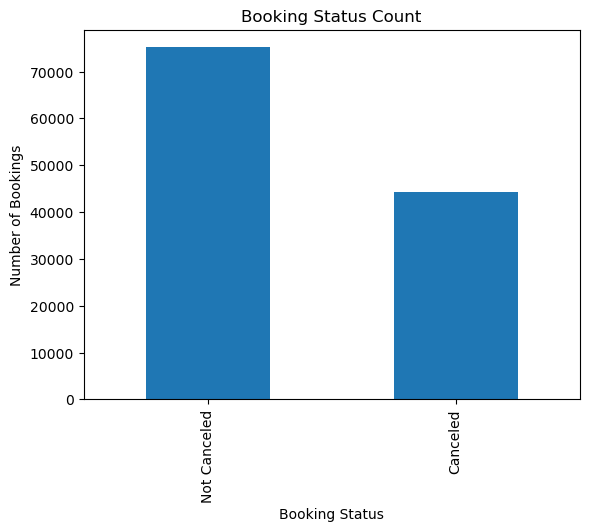

In [25]:
from matplotlib import pyplot as plt
df_explore["booking_status"].value_counts().plot(kind="bar")
plt.title("Booking Status Count")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

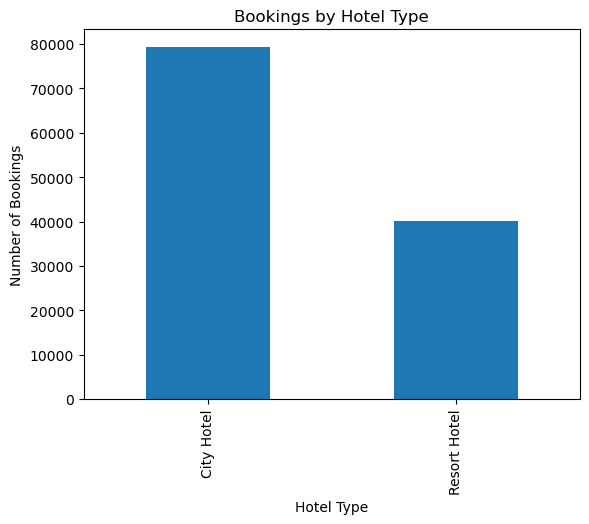

In [26]:
df_explore["hotel"].value_counts()
df_explore["hotel"].value_counts().plot(kind="bar")
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

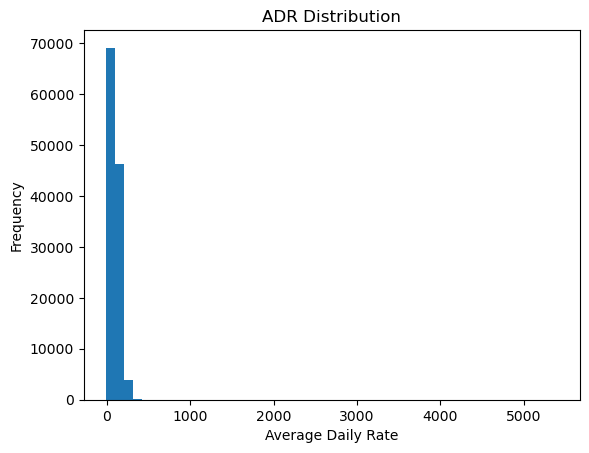

In [27]:
df_explore["adr"].plot(kind="hist", bins=50)
plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.show()

In [28]:
df_explore.groupby("hotel")["adr"].mean().sort_values(ascending=False)

hotel
City Hotel      105.304465
Resort Hotel     94.952930
Name: adr, dtype: float64

In [29]:
monthly_bookings = df_explore["arrival_date_month"].value_counts()
monthly_bookings

August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: arrival_date_month, dtype: int64

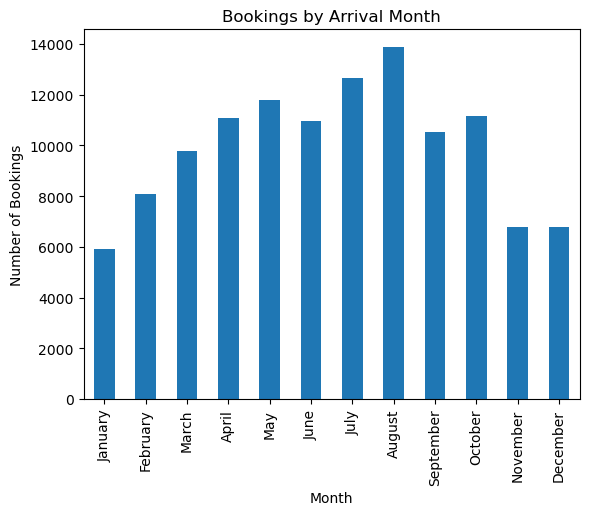

In [30]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_bookings = df_explore["arrival_date_month"].value_counts().reindex(month_order)

monthly_bookings.plot(kind="bar")
plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.show()

In [32]:
df_explore["market_segment"].value_counts()

Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: market_segment, dtype: int64

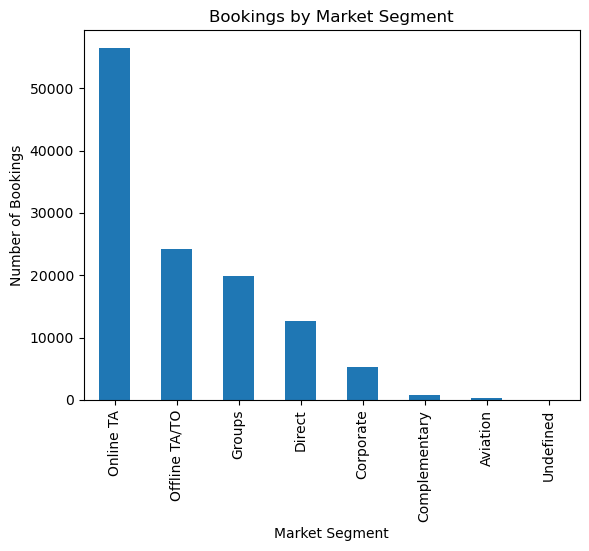

In [31]:
df_explore["market_segment"].value_counts().plot(kind="bar")
plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.show()